<h1 style="text-decoration: underline;">
Case Study: Biotechnological Process Data Analysis
</h1>

### **Breif**

This notebook explores the **“4000 series operating data”** dataset from a large-scale biotechnological process. The dataset contains time-series sensor measurements collected every **5 or 15 minutes** across **22 batches**, capturing the operational state of the process over several hundred hours.

The goal of this analysis is to investigate how **process variables influence product yield**. Using the available operating data and laboratory measurements, we will develop a **data-driven framework** to understand variability in productivity and ultimately predict the yield of an unseen batch.

The key objectives of this notebook are:

1. Explore and understand the structure of the operating and product datasets.
2. Clean and preprocess time-series sensor data (handling missing values, duplicates, and noise).
3. Compute **product rate (kg/hr)** for each batch using laboratory measurements and liquid inflow rates.
4. Rank batches according to productivity.
5. Identify process parameters that correlate with productivity using **machine learning techniques**.
6. Build a predictive model capable of estimating the **product rate of an unseen batch**.

Dataset
Two datasets are used:

- **Operating data** – high-frequency sensor readings (5–15 minute intervals) across **17 process variables**.
- **Product data** – laboratory measurements collected approximately every **4 hours**.

The operating dataset contains approximately **1.4 million observations** across **22 batches**.

The analysis follows a **data engineering → analysis → modelling pipeline**:

1. Data inspection and cleaning
2. Time-series preprocessing
3. Feature extraction at the batch level
4. Statistical and machine learning analysis
5. Predictive modelling

The final outcome will be a **data-driven model identifying the key variables that influence process productivity**.

### **Import modules** & **Load data**

In [3]:
%matplotlib widget

from applied.data_processing import (
    load_operating_data,
    load_product_data,
)

from applied.plotting import BatchTimeSeriesPlotter
from applied.data_processing import BatchTimeSeriesInspector

from pathlib import Path
import numpy as np

In [4]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

### **Data inspection and cleaning (Task1)**

In [5]:
op_df.head()

,Date and time,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,GAS.2,GAS.3,OFFGAS,OFFGAS.1,PRESSURE,PRESSURE.1,OXYGEN
2,2019-02-04 08:46:00,4030,1049.57,25.91,14.44,NaN,297.73,14980.0,5.76,NaN,NaN,NaN,55.14,1.87,16.94,1.79,5.15,6.78
3,2019-02-04 09:01:00,4030,1049.09,25.62,13.54,NaN,357.44,15000.0,5.79,NaN,NaN,NaN,56.88,1.89,20.52,1.80,5.16,8.39
4,2019-02-04 09:16:00,4030,1049.61,25.44,13.59,NaN,356.83,15010.0,5.80,NaN,NaN,NaN,56.03,1.94,23.77,1.80,5.15,8.07
5,2019-02-04 09:31:00,4030,1047.57,25.59,13.97,NaN,356.77,15000.0,5.79,NaN,NaN,NaN,53.91,2.00,27.01,1.80,5.15,7.23
6,2019-02-04 09:46:00,4030,1048.16,25.49,13.43,NaN,357.21,15010.0,5.78,NaN,NaN,NaN,53.97,2.05,30.15,1.80,5.13,7.16


In [6]:
prod_df.head()

,Date and time,Batch,Product
2,2019-02-04 00:00:00,4030,5.9
3,2019-02-04 02:00:00,4030,8.2
4,2019-02-04 04:00:00,4030,9.7
5,2019-02-04 06:00:00,4030,14.3
6,2019-02-04 08:00:00,4030,16.4


In [7]:
inspector = BatchTimeSeriesInspector(op_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

In [8]:
inspector.dataset_summary()

,Metric,Value
0,Rows,83204
1,Columns,18
2,Number of batches,22
3,Date start,2019-02-04 08:46:00
4,Date end,2021-05-25 21:35:00
5,Total NaNs,20897


In [9]:
inspector.inspect_batch(clean_batches)

,Batch,start_time,end_time,duration,resolution,rows
2,4033,2019-05-26 17:16:00,2019-06-23 20:01:00,28 days 02:45:00,0 days 00:15:00,2700
3,4034,2019-07-02 13:01:00,2019-08-03 23:46:00,32 days 10:45:00,0 days 00:15:00,3116
4,4035,2019-08-12 17:46:00,2019-09-08 23:46:00,27 days 06:00:00,0 days 00:15:00,2617
5,4036,2019-09-18 12:16:00,2019-10-20 23:46:00,32 days 11:30:00,0 days 00:15:00,3119
6,4037,2019-10-29 04:01:00,2019-11-20 14:31:00,22 days 10:30:00,0 days 00:15:00,2155
7,4038,2019-12-01 01:01:00,2019-12-30 15:31:00,29 days 14:30:00,0 days 00:15:00,2843
12,4043,2020-06-09 19:16:00,2020-06-28 16:16:00,18 days 21:00:00,0 days 00:15:00,1813
13,4044,2020-07-06 23:46:00,2020-07-20 18:16:00,13 days 18:30:00,0 days 00:15:00,1323
14,4045,2020-07-28 20:31:00,2020-08-11 16:16:00,13 days 19:45:00,0 days 00:15:00,1328
15,4046,2020-08-28 01:59:00,2020-10-04 13:14:00,37 days 11:15:00,0 days 00:15:00,3598


In [10]:
inspector.inspect_batch(unclean_batches)

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,nan_LIQUID,nan_LIQUID.1,nan_LIQUID.2,...,nan_pH,nan_GAS,nan_GAS.1,nan_GAS.2,nan_GAS.3,nan_OFFGAS,nan_OFFGAS.1,nan_PRESSURE,nan_PRESSURE.1,nan_OXYGEN
0,4030,2019-02-04 08:46:00,2019-03-08 08:16:00,31 days 23:30:00,0 days 00:15:00,3071,0,0,0,0,...,0,708,3071,3071,0,0,0,0,0,0
1,4032,2019-04-01 14:16:00,2019-05-03 06:31:00,31 days 16:15:00,0 days 00:15:00,3042,0,0,0,0,...,0,0,1717,2797,0,0,0,0,0,0
8,4039,2020-01-12 11:16:00,2020-01-30 23:46:00,18 days 12:30:00,0 days 00:15:00,1779,0,15,15,16,...,16,16,16,15,16,16,16,16,15,17
9,4040,2020-02-08 11:31:00,2020-03-08 04:01:00,28 days 16:30:00,0 days 00:15:00,2755,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2742,4,0,0,0,...,1,0,0,0,0,2,2,0,1,0
11,4042,2020-04-24 00:16:00,2020-05-29 23:46:00,35 days 23:30:00,0 days 00:15:00,3002,453,4,4,3,...,4,3,4,4,4,4,4,4,3,3
16,4047,2020-10-13 23:29:00,2020-11-13 20:29:00,30 days 21:00:00,0 days 00:15:00,2969,-4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19,4051,2021-01-28 22:50:00,2021-03-01 21:50:00,31 days 23:00:00,0 days 00:05:00,9204,1,407,398,403,...,406,406,403,403,403,402,400,399,403,403
20,4052,2021-03-10 21:05:00,2021-04-13 01:50:00,33 days 04:45:00,0 days 00:05:00,9550,12,0,0,0,...,0,1,0,0,0,7,5,0,0,0
21,4053,2021-04-27 16:35:00,2021-05-25 21:35:00,28 days 05:00:00,0 days 00:05:00,8125,0,0,0,0,...,0,1,0,0,1,7,2,0,0,0


In [11]:
inspector.inspect_batch(4041)

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,nan_pH,nan_OFFGAS,nan_OFFGAS.1,nan_PRESSURE.1
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2742,4,1,2,2,1


LETS VISULAE MISSING DATA HEY 

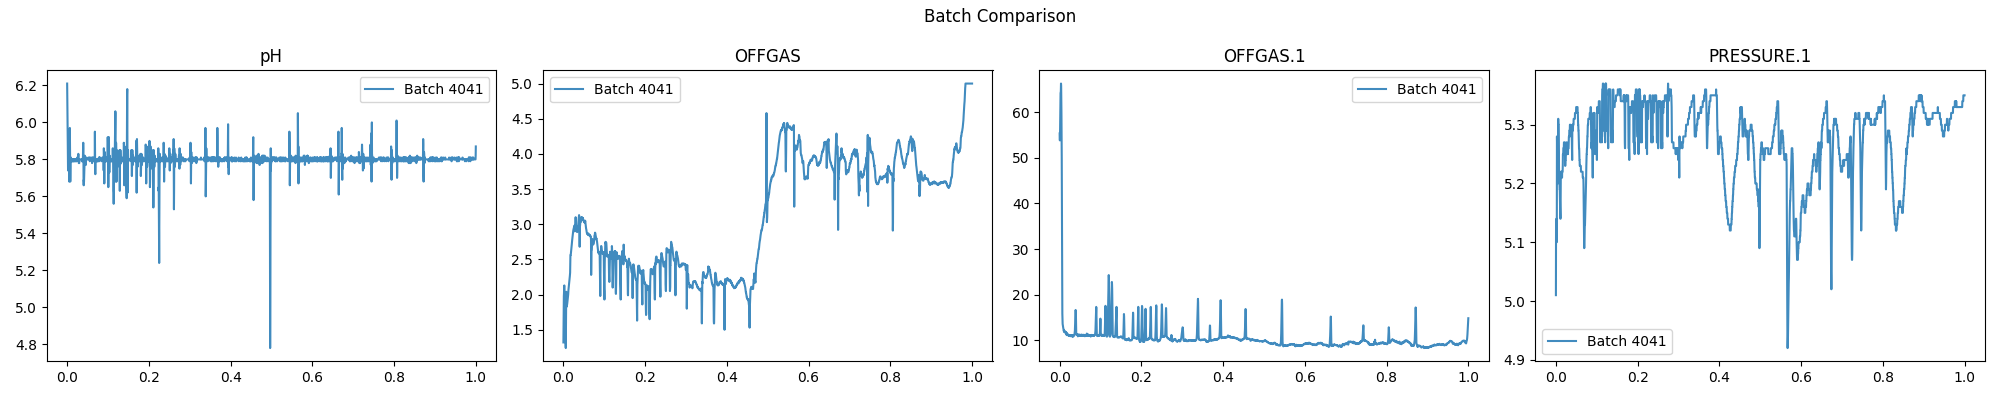

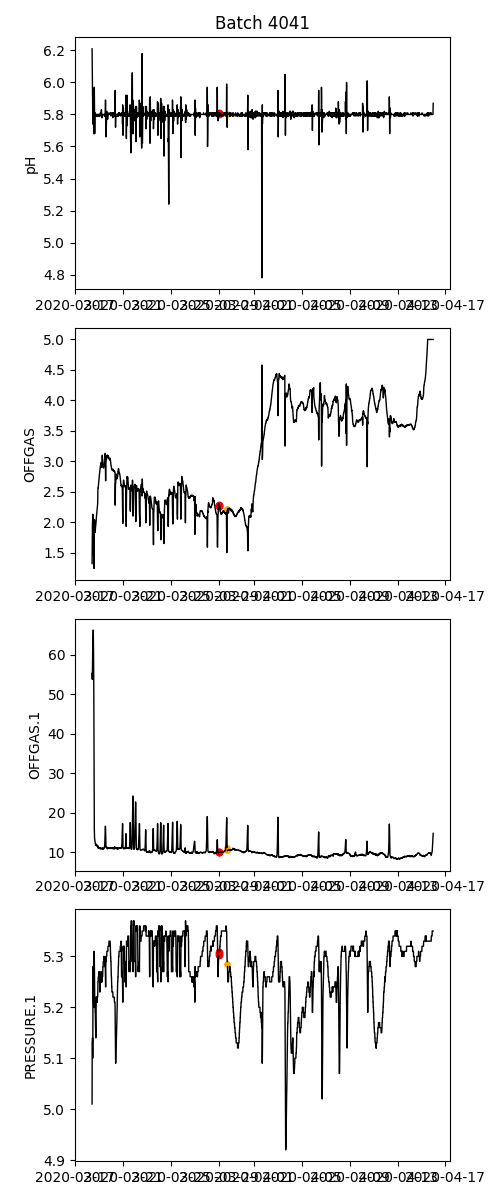

In [12]:
plotter = BatchTimeSeriesPlotter(op_df)


plotter.plot(batch=4041, column=["pH","OFFGAS","OFFGAS.1", 'PRESSURE.1'], width=6)

plotter.plot_batches_grid(columns=["pH","OFFGAS","OFFGAS.1", 'PRESSURE.1'], batches=4041)


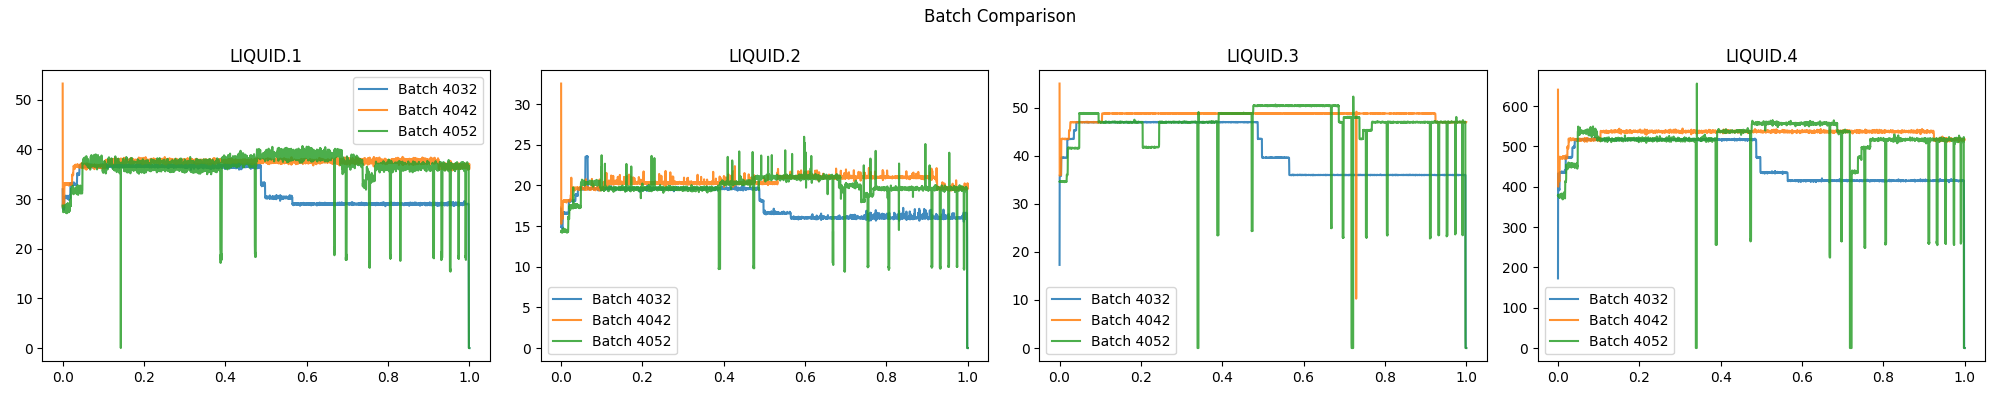

In [13]:
# UPDATE SO ITS THE RIGHT PLOTTER 

plotter = BatchTimeSeriesPlotter(op_df)

plotter.plot(batch=[4032, 4042, 4052], column=["LIQUID.1","LIQUID.2","LIQUID.3", 'LIQUID.4'], width=6)
# plotter.plot(batch=[4032, 4052], column=["GAS",'GAS.1', 'GAS.2', 'GAS.3'])
# plotter.plot(batch=[4032, 4052], column=["PRESSURE",'PRESSURE.1'])

C:\Users\richa\Desktop\Applied\src\applied\plotting.py:380: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


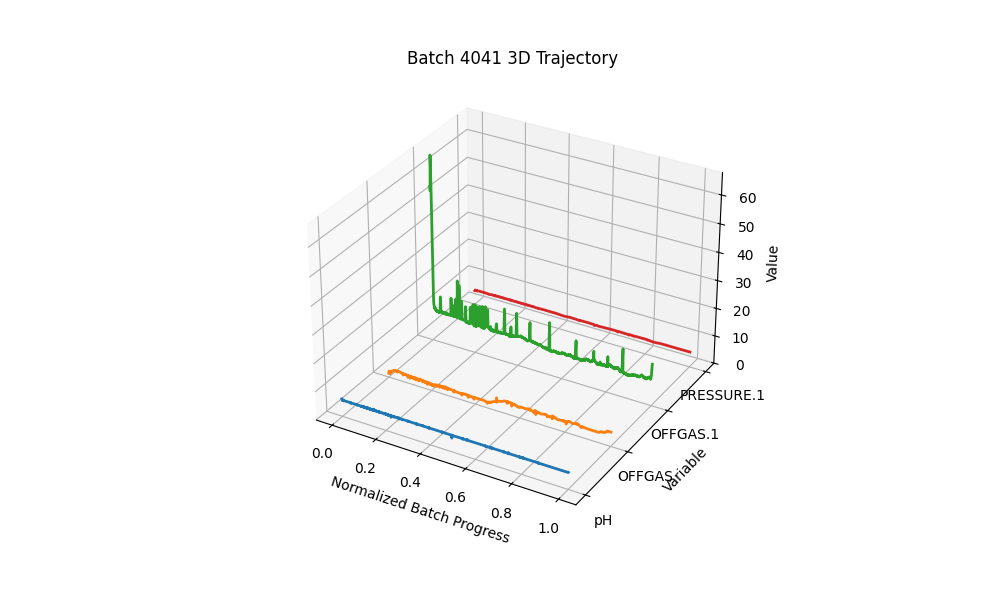

In [14]:
plotter.plot_batch_3d(
    batch=4041,
    columns=["pH","OFFGAS","OFFGAS.1","PRESSURE.1"]
)

NOW NEED TO DO PRODUCTION DATA 

In [15]:
inspector = BatchTimeSeriesInspector(prod_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

### **Ranking productivity of batch Product Rate(Task2&3)**

Compute the **product rate** for each batch using the following formula:

$$
\text{Product Rate (kg/hr)} =
\text{mean product (g/L)} \times
\text{mean total liquid inflow rate (L/hr)} \times 0.001
$$

where the **total liquid inflow rate** is defined as:

$$
\text{Total liquid inflow} =
\sum_{i=1}^{6} \text{liquid inflow}_i
$$

Using the computed product rates, **rank the productivity of the batches**.  
The product rate is a valid comparison metric across batches and is **independent of batch duration**, which is highly variable.

In [16]:
##### ADD THE CLEAN, UNCLEAN TAG


import pandas as pd

def compute_batch_productivity(op_df, prod_df):

    liquid_cols = [
        "LIQUID", "LIQUID.1", "LIQUID.2",
        "LIQUID.3", "LIQUID.4", "LIQUID.5"
    ]

    op_df = op_df.copy()
    prod_df = prod_df.copy()

    # total liquid inflow per row
    op_df["total_liquid_inflow"] = op_df[liquid_cols].sum(axis=1, skipna=True)

    # batch means
    mean_liquid = (
        op_df.groupby("Batch")["total_liquid_inflow"]
        .mean()
        .rename("mean_total_liquid")
    )

    mean_product = (
        prod_df.groupby("Batch")["Product"]
        .mean()
        .rename("mean_product")
    )

    # combine
    batch_product_rate = pd.concat(
        [mean_product, mean_liquid],
        axis=1
    )

    # product rate
    batch_product_rate["product_rate_kg_hr"] = (
        batch_product_rate["mean_product"]
        * batch_product_rate["mean_total_liquid"]
        * 0.001
    )

    # rank batches by productivity
    batch_product_rate = (
        batch_product_rate
        .sort_values("product_rate_kg_hr", ascending=False)
        .assign(productivity_rank=lambda df: range(1, len(df) + 1))
    )

    return batch_product_rate

batch_product_rate = compute_batch_productivity(op_df, prod_df)
batch_product_rate

,mean_product,mean_total_liquid,product_rate_kg_hr,productivity_rank
Batch,,,,
4041,27.263270,24583.602688,670.229408,1
4043,27.041068,24753.736520,669.367477,2
4047,26.370833,25144.553486,663.082829,3
4040,26.450455,24623.509532,651.303020,4
4042,26.367835,24493.636569,645.844169,5
4046,26.017734,24782.597009,644.787017,6
4045,26.591552,24100.309285,640.864621,7
4052,25.787324,24405.554019,629.353928,8
4034,25.052205,24835.980215,622.196071,9


### **Feature Engineering**

TALK ABOUT IN PRESENTATION BRIEFLY AS FUTURE WORK

### **Identifying Process Drivers of Product Rate (Task4)**

Use **machine learning procedures** to identify the **process parameters most clearly related to product rate variability**.

The product rate is defined by the process equation

$$
\text{Product Rate (kg/hr)} =
\text{Mean Product (g/L)} \times
\text{Mean Total Liquid Inflow Rate (L/hr)} \times 0.001
$$

where the total inflow rate is

$$
\text{Total Liquid Inflow} =
\sum_{i=1}^{6} \text{Liquid Inflow}_i
$$

Since the mean total liquid inflow rate is directly measured, it is treated as a known quantity. The machine learning model therefore predicts the **mean product concentration** rather than the product rate itself.

The model learns

$$
\text{Mean Product} = f(\mathbf{x})
$$

where $\mathbf{x}$ represents the observed process features.

The predicted product rate is then computed using the process equation

$$
\widehat{\text{Product Rate}} =
\hat{P} \times
\text{Mean Total Liquid Inflow Rate} \times 0.001
$$

This approach enforces the known physical relationship, reduces the learning burden on the model, and ensures that changes in flow rate are correctly reflected in the predicted product rate.

Modeling Approaches for Predicting Product Formation

Two main modeling strategies can be used to predict product formation in batch processes.

---

1. Batch-Level (Static) Modeling

In batch-level modeling, the full time-series data for each batch is summarized into statistical features (e.g., mean, standard deviation, maximum, totals, trends). A model is then trained to predict the final product concentration directly from these summary features.

The model learns the mapping

$$
\text{Mean Product} = f(\mathbf{x})
$$

where $\mathbf{x}$ represents the vector of batch summary features derived from process measurements.

Once the mean product concentration is predicted, the product rate can be calculated using the known process relationship

$$
\text{Product Rate} =
\text{Mean Product} \times
\text{Mean Total Liquid Inflow Rate} \times 0.001
$$

This approach is often referred to as:

- **Batch-level modeling**
- **Static modeling**
- **Summary-feature modeling**

It is commonly used in industrial process analytics because it is simple, robust, and works well when datasets are relatively small.

---

2. Time-Series (Dynamic / Trajectory) Modeling

In time-series modeling, the full temporal trajectory of the process variables is used rather than summarizing the batch. The model predicts the product concentration at each time step.

The dynamic relationship can be expressed as

$$
P_t = f(P_{t-1}, X_t)
$$

where $P_t$ is the product concentration at time $t$ and $X_t$ represents the process measurements at that time.

The batch mean product concentration can then be computed as

$$
\text{Mean Product} =
\frac{1}{T}\sum_{t=1}^{T} P_t
$$

This approach is commonly referred to as:

- **Time-series modeling**
- **Trajectory modeling**
- **Dynamic modeling**
- **Sequence modeling**

Typical models used for this approach include:

- Recurrent Neural Networks (RNN)
- Long Short-Term Memory networks (LSTM)
- Temporal convolutional models
- State-space models

---

Comparison

| Approach | Data Representation | Typical Models |
|---|---|---|
| Batch-level modeling | Batch summary statistics | Linear models, Random Forest, Gradient Boosting |
| Time-series modeling | Full process trajectory | RNN, LSTM, temporal models |

---

Practical Considerations

Batch-level modeling is more commonly used in industrial applications because it:

- works well with small datasets
- avoids irregular time-sampling issues
- is easier to interpret
- requires less computational complexity

Time-series modeling is more appropriate when the goal is **real-time prediction during the batch**, such as soft sensing or process control.

#### **Batch-Level (Static) Modeling**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [18]:
from applied.data_processing import build_features_and_target
from applied.models import correlation_report

X, y = build_features_and_target(op_df, prod_df)

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error


class ModelEvaluator:

    def __init__(self, op_df, n_splits=5, random_state=42):

        self.random_state = random_state
        self.op_df = op_df

        self.cv = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        # liquid columns used to compute total inflow
        self.liquid_cols = [
            "LIQUID","LIQUID.1","LIQUID.2",
            "LIQUID.3","LIQUID.4","LIQUID.5"
        ]

        # compute batch mean total inflow
        self.inflow = self._compute_mean_total_liquid_inflow()

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.01, max_iter=10000)),
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=800,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                )),
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                )),
            ]),
        }

        self.results = None
        self.importance_df = None


    def _compute_mean_total_liquid_inflow(self):
        """Compute batch mean total liquid inflow."""
        df = self.op_df.copy()

        df["total_liquid"] = df[self.liquid_cols].sum(axis=1)

        inflow = (
            df.groupby("Batch")["total_liquid"]
            .mean()
        )

        return inflow


    def evaluate(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]

        results = {}

        for name, model in self.models.items():

            rmses = []

            for train_idx, test_idx in self.cv.split(X):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                inflow_test = inflow.iloc[test_idx]

                model.fit(X_train, y_train)

                mean_pred = model.predict(X_test)

                rate_pred = mean_pred * inflow_test * 0.001
                rate_true = y_test * inflow_test * 0.001

                rmse = np.sqrt(mean_squared_error(rate_true, rate_pred))
                rmses.append(rmse)

            results[name] = np.mean(rmses)
            print(f"{name}: RMSE (Product Rate) = {results[name]:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        rmse_series = pd.Series(self.results).sort_values(ascending=False)

        plt.figure(figsize=(7,4))

        plt.scatter(rmse_series.index, rmse_series.values)

        for i, v in enumerate(rmse_series.values):
            plt.text(i, v + 0.2, f"{v:.2f}", ha="center")

        plt.ylabel("RMSE (Product Rate)")
        plt.xlabel("Model")
        plt.title("Model Performance Ranking")

        plt.show()


    def compute_permutation_importance(self, X, y, n_repeats=20):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        importance_dict = {}

        for name, model in self.models.items():

            model.fit(X, y)

            perm = permutation_importance(
                model,
                X,
                y,
                n_repeats=n_repeats,
                random_state=self.random_state,
                n_jobs=-1
            )

            importance = pd.Series(
                perm.importances_mean,
                index=X.columns
            )

            importance_dict[name] = importance

        self.importance_df = pd.DataFrame(importance_dict)

        return self.importance_df


    def plot_permutation_importance(self, top_n=10):

        if self.importance_df is None:
            raise ValueError("Run compute_permutation_importance() first.")

        importance_df = self.importance_df.copy()

        top_features = (
            importance_df.mean(axis=1)
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )

        data = importance_df.loc[top_features]

        data.plot(kind="bar", figsize=(10,6))

        plt.title("Permutation Feature Importance Comparison")
        plt.ylabel("Importance")
        plt.xlabel("Features")

        plt.xticks(rotation=45)
        plt.legend(title="Model")

        plt.tight_layout()
        plt.show()


    def plot_inference_comparison1(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]
        rate_true = y * inflow * 0.001

        model_names = list(self.models.keys())
        n_models = len(model_names)

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.flatten()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        lims = [rate_true.min(), rate_true.max()]

        for i, (name, model) in enumerate(self.models.items()):

            ax = axes[i]
            color = colors[i]

            model.fit(X, y)

            mean_pred = model.predict(X)
            rate_pred = mean_pred * inflow * 0.001

            df = pd.DataFrame({
                "true": rate_true,
                "pred": rate_pred
            }).sort_values("true")

            # actual points
            ax.scatter(
                df["true"],
                df["pred"],
                color="black",
                alpha=0.5,
                s=30
            )

            # model prediction line
            ax.plot(
                df["true"],
                df["pred"],
                color=color,
                linewidth=2,
                label=name
            )

            # perfect prediction line
            ax.plot(lims, lims, "k--", linewidth=1)

            ax.set_title(name)
            ax.set_xlabel("Actual Product Rate")
            ax.set_ylabel("Predicted Product Rate")

        # remove unused subplot (since 5 models)
        for j in range(n_models, 6):
            fig.delaxes(axes[j])

        plt.suptitle("Inference Comparison Across Models", fontsize=14)
        plt.tight_layout()
        plt.show()



        

    def plot_inference_comparison(self, X, y):

        from sklearn.model_selection import cross_val_predict

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]
        rate_true = y * inflow * 0.001

        model_names = list(self.models.keys())
        n_models = len(model_names)

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.flatten()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        lims = [rate_true.min(), rate_true.max()]

        for i, (name, model) in enumerate(self.models.items()):

            ax = axes[i]
            color = colors[i]

            # out-of-fold predictions
            mean_pred = cross_val_predict(
                model,
                X,
                y,
                cv=self.cv,
                n_jobs=-1
            )

            rate_pred = mean_pred * inflow * 0.001

            df = pd.DataFrame({
                "true": rate_true,
                "pred": rate_pred
            }).sort_values("true")

            # predicted points
            ax.scatter(
                df["true"],
                df["pred"],
                color="black",
                alpha=0.6,
                s=30
            )

            # smooth trend line
            ax.plot(
                df["true"],
                df["pred"],
                color=color,
                linewidth=2,
                label=name
            )

            # perfect prediction line
            ax.plot(lims, lims, "k--", linewidth=1)

            ax.set_title(name)
            ax.set_xlabel("Actual Product Rate")
            ax.set_ylabel("Predicted Product Rate")

        # remove unused subplot
        for j in range(n_models, 6):
            fig.delaxes(axes[j])

        plt.suptitle("Inference Comparison Across Models (Cross-Validated)", fontsize=14)
        plt.tight_layout()
        plt.show()

Ridge: RMSE (Product Rate) = 37.8945
Lasso: RMSE (Product Rate) = 10.9279
ElasticNet: RMSE (Product Rate) = 14.6602
RandomForest: RMSE (Product Rate) = 24.0711
HistGradientBoosting: RMSE (Product Rate) = 36.0097


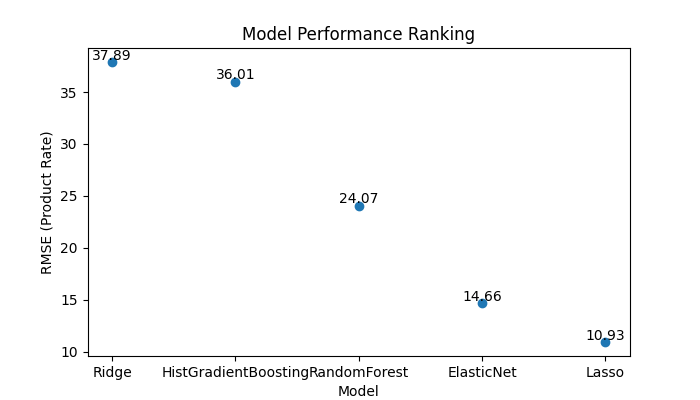

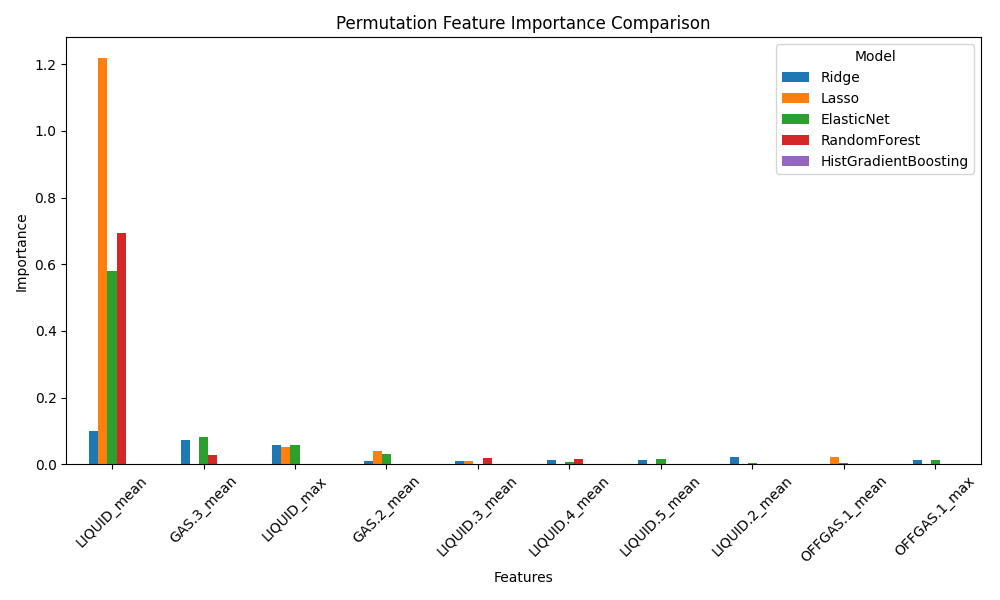

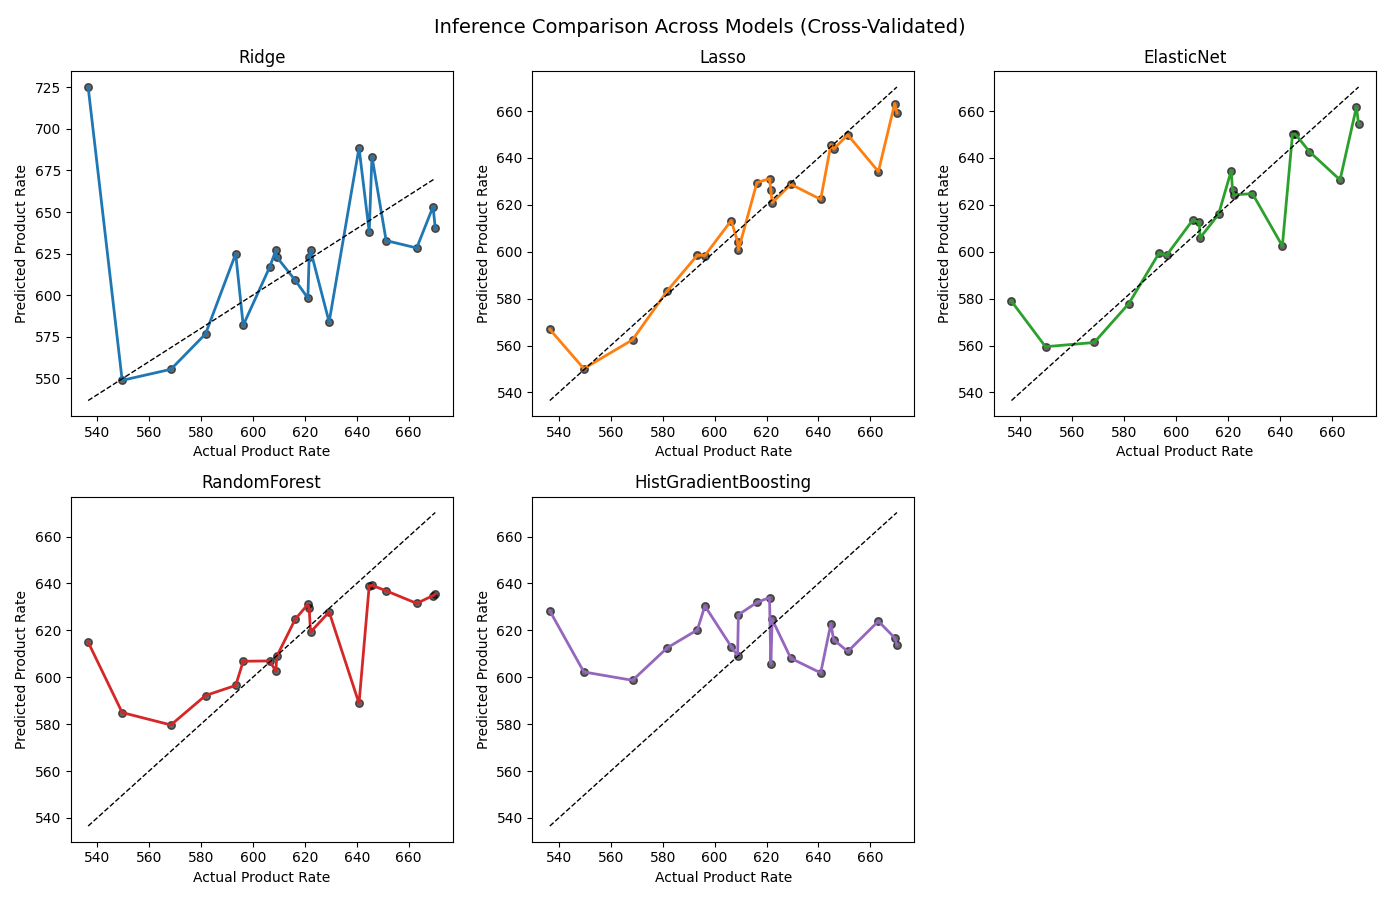

In [48]:
evaluator = ModelEvaluator(op_df)

evaluator.evaluate(X, y)

evaluator.plot_model_rmse()

evaluator.compute_permutation_importance(X, y)

evaluator.plot_permutation_importance(top_n=10)

evaluator.plot_inference_comparison(X, y)

NEED TO BE MORE CLEAR WHAT VAL_TRAIN IS 

NEED TO HYPERTUNE FIT EACH MODEL 

THEN DO MODEL COMPARISON 

NEED TO BE SURE FEATURE IMPORTANCTE IS RELATIVE TO PREDICTING MEAN_PRODUCT 

LOOK AT FEATURE TO FEATURE AND GET RID OF CLOSE CORRELATION FOR SAME FEATURE TO SEE WHAT REMAINS - eg spearte signals 

In [19]:
feature_corr = correlation_report(X, threshold=0.8, mode="feature")
target_corr = correlation_report(X, y, threshold=0.7, mode="target")
features = target_corr["Feature"].tolist()

print(feature_corr, '\n\n', target_corr)

       Feature_1       Feature_2  Correlation
0   LIQUID.2_min    LIQUID.4_min     0.999997
1   LIQUID.1_sum    LIQUID.4_sum     0.999904
2   LIQUID.1_min    LIQUID.4_min     0.999902
3   LIQUID.1_min    LIQUID.2_min     0.999865
4   LIQUID.2_sum    LIQUID.4_sum     0.999660
..           ...             ...          ...
84  LIQUID.2_std  PRESSURE.1_std     0.821345
85    GAS.2_mean       GAS.2_std     0.815736
86  LIQUID.1_std  PRESSURE.1_std     0.812375
87  LIQUID.4_std    PRESSURE_std     0.806238
88     GAS.3_std          pH_std     0.804199

[89 rows x 3 columns] 

        Feature  Correlation_with_Target
0  LIQUID_mean                 0.949425
1   GAS.3_mean                 0.831788


In [58]:
### ALSO need to be clear what validation im doing for presentation - 

### I got to get a visuale of the inference curve fits 

### THEN I also need to quicly expirment predict product mean since not to learn linear relationship with liquid as this is given 

#### do Kamal model 

#### THEN point to features that are commoan and specifc for model 

#### section done

#### **Time-Series (Dynamic / Trajectory) Modeling**

### **Constructing a Predictive Model (Task5)**

Construct a **mathematical and/or computational model** that incorporates the insights from **Task 4** into a **predictive framework**.

Predictive Model Construction

Based on the feature importance analysis in Task 4, a reduced predictive framework was constructed using the most influential process parameters.

A Random Forest regressor was selected due to its superior cross-validated performance and ability to model non-linear interactions between process variables.

Predictive form:

y_hat = f(P, G_in, G_off, O2, L_in, pH)

where f(.) is a non-linear ensemble mapping learned via bootstrap aggregation of decision trees.

Cross-validation was used to estimate generalisation performance.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Reduced feature set from Task 4
X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

# Predictive framework
framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    framework,
    X_reduced,
    y_target,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

print(f"Cross-validated RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Cross-validated RMSE: 14.197 ± 5.504


Train/test split + performance metrics

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_target, test_size=0.2, random_state=42
)

framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

framework.fit(X_train, y_train)
y_pred = framework.predict(X_test)

# RMSE compatible with older sklearn:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 7.735
Test MAE:  6.864
Test R²:   0.872


Predicted Vs Actual

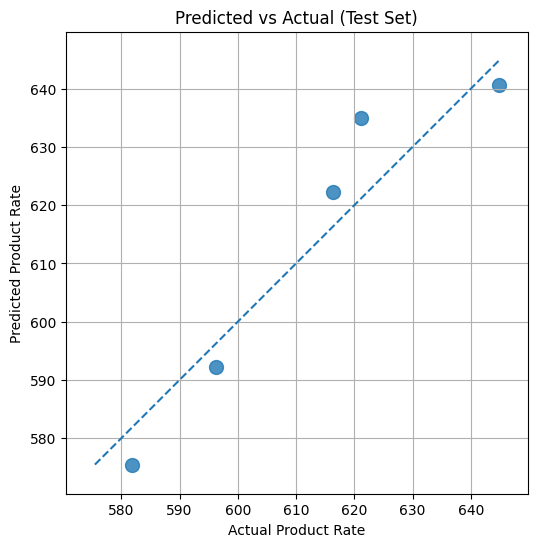

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=100, alpha=0.8)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Product Rate")
plt.ylabel("Predicted Product Rate")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted versus actual plot demonstrates reasonable alignment with the 1:1 reference line, indicating that the Random Forest model captures a substantial proportion of productivity variability across batches. Most predictions lie close to the ideal line, although the highest productivity batch is moderately underpredicted, suggesting mild regression toward the mean. This behaviour is typical of ensemble tree models trained on relatively small datasets. Overall, the model exhibits stable generalisation performance without evidence of systematic bias.

Residuals Vs Pred

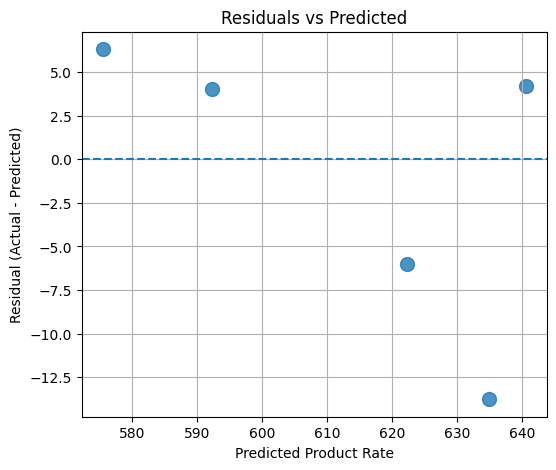

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, s=100, alpha=0.8)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Product Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid(True)

plt.show()

Residuals are distributed around zero without clear structural pattern, indicating that the model does not exhibit strong systematic bias across the prediction range.

In [30]:
import pandas as pd

pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

,Metric,Value
0,RMSE,7.735395
1,MAE,6.863963
2,R²,0.872102


### **Predicting the Missing Yield Rate (Task6)**

Use the developed model to **predict the “missing” yield rate**.